# 3. Merge, Filter, Feature Importance

In [119]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lightgbm as lgb

from scipy.stats import chi2_contingency
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler


In [121]:
# 1. Use scan_csv to point to the files without loading them fully
demo_new = pl.scan_csv("C:/Documents/VSCODE/Fixing IR Preprocessing/Data/new_individual_data/clean_demo_2025.csv")
drug_new = pl.scan_csv("C:/Documents/VSCODE/Fixing IR Preprocessing/Data/new_individual_data/clean_drug_top10.csv")
reac_new = pl.scan_csv("C:/Documents/VSCODE/Fixing IR Preprocessing/Data/new_individual_data/clean_reaction_top10.csv")
outc_new = pl.scan_csv("C:/Documents/VSCODE/Fixing IR Preprocessing/Data/new_individual_data/clean_outcome_2025.csv")

#### Step 1: Merge tables

In [122]:
outc_new

In [123]:
# 2. Group ALL columns for each secondary table
# pl.all().exclude([...]) tells Polars to bundle everything EXCEPT the join keys
drug_grouped = drug_new.group_by(["primaryid", "caseid"]).agg(
    pl.all().exclude(["primaryid", "caseid"])
)

reac_grouped = reac_new.group_by(["primaryid", "caseid"]).agg(
    pl.all().exclude(["primaryid", "caseid"])
)

outc_grouped = outc_new.group_by(["primaryid", "caseid"]).agg(
    pl.all().exclude(["primaryid", "caseid"])
)

# 3. Join everything back to Demo with UNIQUE suffixes
# suffix stores the original index
final_lazy_grouped = (
    demo_new
    .join(drug_grouped, on=["primaryid", "caseid"], how="left", suffix="_drug")
    .join(reac_grouped, on=["primaryid", "caseid"], how="left", suffix="_reac")
    .join(outc_grouped, on=["primaryid", "caseid"], how="left", suffix="_outc")
)

In [124]:
final_lazy_grouped = final_lazy_grouped.drop(["_reac", "_outc", "_drug"])

In [125]:
final_lazy_grouped.head(5).collect()

,primaryid,caseid,caseversion,i_f_code,rept_cod,e_sub,occp_cod,occr_country,mfr_num_clean,mfr_sndr_clean,sex_clean,reporter_country_clean,mfr_dt_clean,rept_dt_clean,init_fda_dt_clean,fda_dt_clean,age_yrs_clean,drug_seq,role_cod,prod_ai,val_vbm,dechal,drugname_clean,pt_clean,outc_cod
i64,i64,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,list[i64],list[str],list[str],list[i64],list[str],list[str],list[str],list[str]
1236705,19454468151,19454468,151,"""F""","""EXP""","""Y""","""HP""","""CA""","""CA-PFIZER INC-2019070530""","""BIOCON""",null,"""CA""","""2025-12-01""","""2025-12-12""",null,null,null,"[18, 28, … 246]","[""SS"", ""SS"", … ""SS""]","[""ACETAMINOPHEN"", ""INFLIXIMAB"", … ""VEDOLIZUMAB""]","[1, 1, … 1]","[""U"", ""N"", … ""U""]","[""ACETAMINOPHEN"", ""INFLIXIMAB"", … ""VEDOLIZUMAB""]","[""HEADACHE"", ""NAUSEA""]","[""HO"", ""OT""]"
1240221,21684576150,21684576,150,"""F""","""EXP""","""Y""","""HP""","""CA""","""CA-PFIZER INC-202201346146""","""PFIZER""","""M""","""CA""","""2025-11-11""","""2025-11-24""",null,null,80,"[218, 219, … 228]","[""SS"", ""SS"", … ""SS""]","[""ACETAMINOPHEN"", ""ACETAMINOPHEN"", … ""ACETAMINOPHEN""]","[1, 1, … 1]","[""D"", ""D"", … ""D""]","[""ACETAMINOPHEN"", ""ACETAMINOPHEN"", … ""ACETAMINOPHEN""]","[""INFECTION"", ""INFECTION"", … ""NAUSEA""]","[""OT"", ""HO"", … ""LT""]"
801301,19454468150,19454468,150,"""F""","""EXP""","""Y""","""HP""","""CA""","""CA-PFIZER INC-2019070530""","""PFIZER""","""F""","""CA""","""2025-07-17""","""2025-07-29""",null,null,71,"[3, 4, … 200]","[""SS"", ""SS"", … ""SS""]","[""INFLIXIMAB-DYYB"", ""INFLIXIMAB-DYYB"", … ""ACETAMINOPHEN""]","[1, 1, … 1]","[""N"", ""N"", … ""U""]","[""INFLECTRA"", ""INFLECTRA"", … ""ACETAMINOPHEN""]","[""HEADACHE"", ""NAUSEA""]","[""HO"", ""OT""]"
406961,19454468148,19454468,148,"""F""","""EXP""","""Y""","""HP""","""CA""","""CA-PFIZER INC-2019070530""","""PFIZER""","""F""","""CA""","""2025-04-22""","""2025-05-02""",null,null,71,"[3, 4, … 200]","[""SS"", ""SS"", … ""SS""]","[""INFLIXIMAB-DYYB"", ""INFLIXIMAB-DYYB"", … ""ACETAMINOPHEN""]","[1, 1, … 1]","[""N"", ""N"", … ""U""]","[""INFLECTRA"", ""INFLECTRA"", … ""ACETAMINOPHEN""]","[""NAUSEA"", ""HEADACHE""]","[""HO"", ""OT""]"
6578,19454468146,19454468,146,"""F""","""EXP""","""Y""","""MD""","""CA""","""CA-PFIZER INC-2019070530""","""PFIZER""","""F""","""CA""","""2025-03-20""","""2025-03-31""",null,null,71,"[3, 4, … 200]","[""SS"", ""SS"", … ""SS""]","[""INFLIXIMAB-DYYB"", ""INFLIXIMAB-DYYB"", … ""ACETAMINOPHEN""]","[1, 1, … 1]","[""N"", ""N"", … ""U""]","[""INFLECTRA"", ""INFLECTRA"", … ""ACETAMINOPHEN""]","[""HEADACHE"", ""NAUSEA""]","[""HO"", ""OT""]"


In [126]:
# Check if row count equals unique case count
stats = final_lazy_grouped.select([
    pl.len().alias("total_rows"),
    pl.col("caseid").n_unique().alias("unique_cases")
]).collect()

print(stats)

shape: (1, 2)
┌────────────┬──────────────┐
│ total_rows ┆ unique_cases │
│ ---        ┆ ---          │
│ u32        ┆ u32          │
╞════════════╪══════════════╡
│ 1617313    ┆ 1469305      │
└────────────┴──────────────┘


Each row is one caseid. All columns are joined as a list. However, null can be observed after matching.

#### Step 2. Rule-Based Filtering

##### 1. Removing rows where prod_ai or pt is null

In [127]:
# Count nulls per column across the rows
null_counts = (
    final_lazy_grouped
    .select([
        pl.all().is_null().sum()
    ])
    .collect()
)

null_counts

,primaryid,caseid,caseversion,i_f_code,rept_cod,e_sub,occp_cod,occr_country,mfr_num_clean,mfr_sndr_clean,sex_clean,reporter_country_clean,mfr_dt_clean,rept_dt_clean,init_fda_dt_clean,fda_dt_clean,age_yrs_clean,drug_seq,role_cod,prod_ai,val_vbm,dechal,drugname_clean,pt_clean,outc_cod
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,224400,79563,54368,2159,320929,2465,2604,550,565638,565645,642046,1232685,1232685,1232685,1232685,1232685,1232685,1148580,697686


In [128]:
cleaned_lazy = final_lazy_grouped.filter(
    pl.col("prod_ai").is_not_null() & 
    pl.col("pt_clean").is_not_null()
)

print(f"Rows remaining: {cleaned_lazy.select(pl.len()).collect().item():,}")

Rows remaining: 142,228


In [129]:
# Check if row count equals unique case count
stats = cleaned_lazy.select([
    pl.len().alias("total_rows"),
    pl.col("caseid").n_unique().alias("unique_cases")
]).collect()

print(stats)

shape: (1, 2)
┌────────────┬──────────────┐
│ total_rows ┆ unique_cases │
│ ---        ┆ ---          │
│ u32        ┆ u32          │
╞════════════╪══════════════╡
│ 142228     ┆ 122923       │
└────────────┴──────────────┘


In [130]:
# Count nulls per column across the 93M rows
null_counts = (
    cleaned_lazy
    .select([
        pl.all().is_null().sum()
    ])
    .collect()
)

null_counts

,primaryid,caseid,caseversion,i_f_code,rept_cod,e_sub,occp_cod,occr_country,mfr_num_clean,mfr_sndr_clean,sex_clean,reporter_country_clean,mfr_dt_clean,rept_dt_clean,init_fda_dt_clean,fda_dt_clean,age_yrs_clean,drug_seq,role_cod,prod_ai,val_vbm,dechal,drugname_clean,pt_clean,outc_cod
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,19830,2361,1410,31,17244,126,81,40,72401,72401,36553,0,0,0,0,0,0,0,72875


In [131]:
df = cleaned_lazy.collect()
df.shape

(142228, 26)

#### Step 3: Identifying target and predictors (droping irrelavent cols)

In [132]:
df.columns

['',
 'primaryid',
 'caseid',
 'caseversion',
 'i_f_code',
 'rept_cod',
 'e_sub',
 'occp_cod',
 'occr_country',
 'mfr_num_clean',
 'mfr_sndr_clean',
 'sex_clean',
 'reporter_country_clean',
 'mfr_dt_clean',
 'rept_dt_clean',
 'init_fda_dt_clean',
 'fda_dt_clean',
 'age_yrs_clean',
 'drug_seq',
 'role_cod',
 'prod_ai',
 'val_vbm',
 'dechal',
 'drugname_clean',
 'pt_clean',
 'outc_cod']

##### Drop immediately (before any analysis) — administrative/system columns:


* '', Unnamed: 0, Unnamed: 0_drug, Unnamed: 0_reac, Unnamed: 0_outc — index artifacts
* primaryid, caseversion — identifiers, no predictive value (caseid kept as index, will remove before training)
* drug_seq — sequence number, not meaningful
* val_vbm — validation flag, administrative


In [133]:
drop_cols = [
    '',                    # blank index
    'primaryid',
    'caseversion',
    'drug_seq',
    'val_vbm'
]

data_cleaned = df.drop(drop_cols)

##### Drop at Literature Review stage — reporting/administrative variables:


* mfr_sndr_clean, mfr_num_clean — manufacturer, reporting bias
* occp_cod — reporter occupation
* i_f_code, rept_cod, e_sub — report type/source flags, not patient/drug related
* mfr_dt_clean, rept_dt_clean, init_fda_dt_clean, fda_dt_clean — reporting dates, not clinical
* reporter_country_clean — redundant with occr_country
* outc_cod - data leakage and missing

In [134]:
data_cleaned.columns

['caseid',
 'i_f_code',
 'rept_cod',
 'e_sub',
 'occp_cod',
 'occr_country',
 'mfr_num_clean',
 'mfr_sndr_clean',
 'sex_clean',
 'reporter_country_clean',
 'mfr_dt_clean',
 'rept_dt_clean',
 'init_fda_dt_clean',
 'fda_dt_clean',
 'age_yrs_clean',
 'role_cod',
 'prod_ai',
 'dechal',
 'drugname_clean',
 'pt_clean',
 'outc_cod']

In [135]:
drop_cols = [
    'mfr_sndr_clean', 
    'mfr_num_clean',
    'occp_cod',
    'i_f_code', 
    'rept_cod', 
    'e_sub',
    'mfr_dt_clean', 
    'rept_dt_clean', 
    'init_fda_dt_clean', 'fda_dt_clean',
    'reporter_country_clean',
    'outc_cod',
    'dechal',
    'role_cod'
]

drop_cols = [c for c in drop_cols if c in data_cleaned.columns]
data_cleaned = data_cleaned.drop(drop_cols)

In [136]:
data_cleaned.columns

['caseid',
 'occr_country',
 'sex_clean',
 'age_yrs_clean',
 'prod_ai',
 'drugname_clean',
 'pt_clean']

In [137]:
# 1️ Convert cleaned Polars DF to pandas
data_pd = data_cleaned.to_pandas()

In [138]:
# 2 Select features for clustering
feature_cols = [
 'occr_country',
 'sex_clean',
 'age_yrs_clean',
 'prod_ai',
 'drugname_clean',
 'pt_clean'
    
]
data_subset = data_pd[feature_cols].copy()

In [139]:
# 3️ Flatten any list/array values
# If a cell contains a list or np.ndarray, take first element
# If empty list/array, replace with NaN
def flatten_cell(x):
    if isinstance(x, (list, np.ndarray)):
        return x[0] if len(x) > 0 else np.nan
    return x

for col in feature_cols:
    data_subset[col] = data_subset[col].apply(flatten_cell)

In [140]:
data_subset.isna().sum()

occr_country       2361
sex_clean         17244
age_yrs_clean     36553
prod_ai               0
drugname_clean        0
pt_clean              0
dtype: int64

In [141]:
# 4️ Bin numeric column (age_yrs_clean) into categories

bins = [0, 18, 35, 50, 65, 100]
labels = ['0-18','19-35','36-50','51-65','65+']
data_subset['age_yrs_clean'] = pd.cut(data_subset['age_yrs_clean'], bins=bins, labels=labels)

# Fill missing ages with a new category
data_subset['age_yrs_clean'] = data_subset['age_yrs_clean'].cat.add_categories('missing').fillna('missing')

In [142]:
# 5️ Convert all categorical columns to 'category'
cat_cols = [
    'occr_country','sex_clean', 'age_yrs_clean',
    'prod_ai', 'drugname_clean','pt_clean'
]

for col in cat_cols:
    data_subset[col] = data_subset[col].astype('category')

In [143]:
# 6️ Bias-corrected Cramér's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    
    if rcorr <= 1 or kcorr <= 1:  # avoid division by zero
        return np.nan
    
    return np.sqrt(phi2corr / min(kcorr-1, rcorr-1))

In [144]:
# 7️ Compute Cramér's V matrix
cramers_matrix = pd.DataFrame(
    np.zeros((len(feature_cols), len(feature_cols))),
    index=feature_cols,
    columns=feature_cols
)

for col1 in feature_cols:
    for col2 in feature_cols:
        if col1 == col2:
            cramers_matrix.loc[col1, col2] = 1.0  # self-association
        else:
            cramers_matrix.loc[col1, col2] = cramers_v(
                data_subset[col1],
                data_subset[col2]
            )

In [145]:
# 8️ Distance matrix
distance_matrix = 1 - cramers_matrix

# Fill NaNs with 1 (max distance)
distance_matrix_filled = distance_matrix.fillna(1)

# Ensure symmetry
distance_matrix_symmetric = (distance_matrix_filled + distance_matrix_filled.T) / 2

# Set diagonal to 0
np.fill_diagonal(distance_matrix_symmetric.values, 0)

# Convert to condensed distance format
condensed_dist = squareform(distance_matrix_symmetric.values)

In [146]:
# Perform hierarchical clustering using the condensed distance matrix
linkage_matrix = linkage(condensed_dist, method='average')  # 'average', 'complete', 'single', etc.

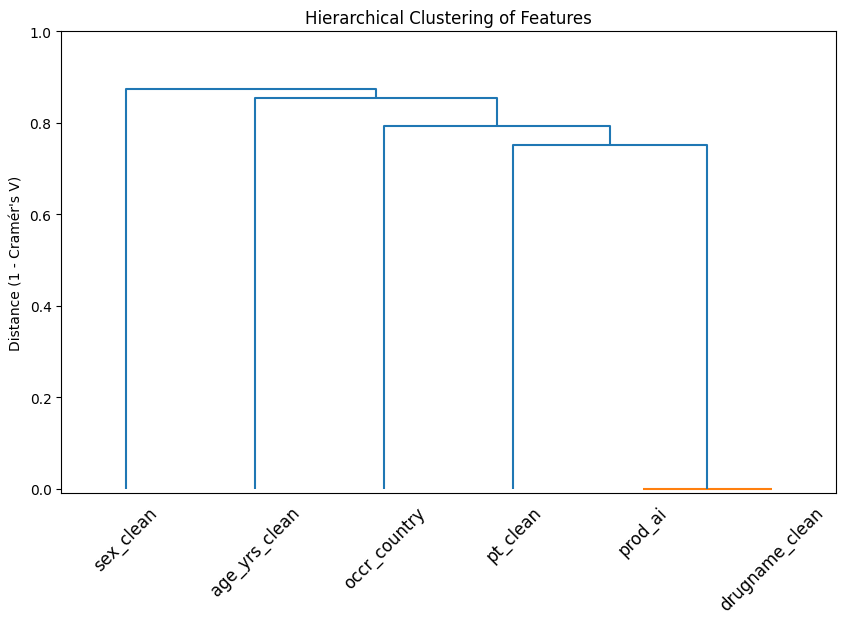

In [147]:
plt.figure(figsize=(10, 6))
dendrogram(
    linkage_matrix,
    labels=feature_cols,   
    leaf_rotation=45,
    leaf_font_size=12,
    color_threshold=0.5    
)
plt.ylim(-0.01, 1.0)
plt.title("Hierarchical Clustering of Features")
plt.ylabel("Distance (1 - Cramér's V)")
plt.show()

##### Drop After Hierarchical Clustering

In [148]:
df_filtered = data_cleaned
df_filtered = df_filtered.drop('drugname_clean')

In [149]:
df_filtered.columns

['caseid', 'occr_country', 'sex_clean', 'age_yrs_clean', 'prod_ai', 'pt_clean']

In [150]:
df_filtered.shape

(142228, 6)

In [151]:
df_filtered.head()

caseid,occr_country,sex_clean,age_yrs_clean,prod_ai,pt_clean
i64,str,str,i64,list[str],list[str]
25289803,null,null,71,"[""PREDNISONE""]","[""HEADACHE""]"
20684945,"""US""","""F""",66,"[""ACETAMINOPHEN""]","[""FATIGUE"", ""INFECTION""]"
24805074,null,"""F""",null,"[""ACETAMINOPHEN""]","[""DYSPNOEA"", ""INFECTION""]"
15461621,"""US""","""F""",57,"[""ACETAMINOPHEN""]","[""INJECTION_SITE_REACTION"", ""INJECTION_SITE_REACTION"", … ""INFECTION""]"
25948320,"""US""","""F""",42,"[""DUPILUMAB"", ""DUPILUMAB""]","[""FATIGUE"", ""INJECTION_SITE_REACTION""]"


In [152]:
stats = df_filtered.select([
    pl.len().alias("total_rows"),
    pl.col("caseid").n_unique().alias("unique_cases")
])

print(stats)

shape: (1, 2)
┌────────────┬──────────────┐
│ total_rows ┆ unique_cases │
│ ---        ┆ ---          │
│ u32        ┆ u32          │
╞════════════╪══════════════╡
│ 142228     ┆ 122923       │
└────────────┴──────────────┘


#### Step 4: Explode into flat table

In [169]:
# Check if row count equals unique case count
stats = df_filtered.select([
    pl.len().alias("total_rows"),
    pl.col("caseid").n_unique().alias("unique_cases")
])

print(stats)

shape: (1, 2)
┌────────────┬──────────────┐
│ total_rows ┆ unique_cases │
│ ---        ┆ ---          │
│ u32        ┆ u32          │
╞════════════╪══════════════╡
│ 142228     ┆ 122923       │
└────────────┴──────────────┘


In [170]:
# 1️ Explode only prod_ai
df_flat = df_filtered.explode(["prod_ai"])

# 2️ Remove exact duplicates (same case + drug)
df_flat = df_flat.unique(subset=["caseid", "prod_ai"])

# 3️ Collapse back to one row per case 
df_flat = df_flat.group_by("caseid").agg(
    pl.col("prod_ai").implode(),      
    pl.all().exclude(["caseid", "prod_ai"]).first() 
)

# 4️ Get all drugs present in data (already pre-scoped to top 10)
all_drugs = df_flat["prod_ai"].explode().unique().drop_nulls().to_list()

# 5️ Create binary columns for each drug
for drug in all_drugs:
    df_flat = df_flat.with_columns(
        pl.col("prod_ai")
        .list.contains(drug)
        .cast(pl.Int8)
        .alias(f"drug_{drug}")
    )

# 6️ Get all reactions present in data (already pre-scoped to top 10)
all_reactions = df_flat["pt_clean"].explode().unique().drop_nulls().to_list()

# 7️ Create binary columns for each reaction
for reaction in all_reactions:
    df_flat = df_flat.with_columns(
        pl.col("pt_clean")
        .list.contains(reaction)
        .cast(pl.Int8)
        .alias(f"reaction_{reaction}")
    )

# 8️ Drop the original list columns
df_final = df_flat.drop(["pt_clean", "prod_ai"])

In [171]:
df_final.head(15)

caseid,occr_country,sex_clean,age_yrs_clean,drug_PREDNISONE,drug_DUPILUMAB,drug_RITUXIMAB,drug_METHOTREXATE,drug_INFLIXIMAB-DYYB,drug_VEDOLIZUMAB,drug_ACETAMINOPHEN,drug_TIRZEPATIDE,drug_TOCILIZUMAB,drug_INFLIXIMAB,reaction_DIARRHOEA,reaction_RASH,reaction_NAUSEA,reaction_DYSPNOEA,reaction_INFECTION,reaction_PSYCHIATRIC_EVENT,reaction_FATIGUE,reaction_DEATH,reaction_INJECTION_SITE_REACTION,reaction_HEADACHE
i64,str,str,i64,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8
26208151,"""EU""","""M""",30,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
25629271,"""US""","""F""",5,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
24821429,"""US""","""F""",48,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
25505008,null,"""F""",62,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
25951083,"""US""",null,56,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
25506848,"""US""","""F""",null,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
24126715,"""US""","""M""",null,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
24936912,"""PT""","""F""",43,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0


In [172]:
df_final.shape

(122923, 24)

#### Step 5: Export Parquet

In [174]:
df_final.write_parquet('C:/Documents/VSCODE/Fixing IR Preprocessing/Data/adverse_events_drug_level_new.parquet')  